<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/gcc_phat_tdoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GCC-PHAT: Time Delay Estimation Between Two Microphone Signals

**Generalized Cross-Correlation with Phase Transform (GCC-PHAT)**

This notebook estimates the **Time Difference of Arrival (TDOA)** between two microphone signals using GCC-PHAT — the core algorithm for acoustic source localization (gunshot detection, speech DOA, etc.).

**Reference implementation:** [`respeaker/mic_array/gcc_phat.py`](https://github.com/respeaker/mic_array/blob/master/gcc_phat.py) (Apache 2.0)  
**Algorithm description:** [Xavier Anguera Ph.D. thesis, Node 92](http://www.xavieranguera.com/phdthesis/node92.html)

---

### How GCC-PHAT works

$$R_{\text{GCC-PHAT}}(\tau) = \mathcal{F}^{-1}\left\{ \frac{X_1(f) \cdot X_2^*(f)}{|X_1(f) \cdot X_2^*(f)|} \right\}$$

The PHAT weighting `/ |R|` whitens the cross-power spectrum, making the peak **sharp** and robust against colored noise — ideal for impulsive sounds like gunshots.

$$\hat{\tau} = \arg\max_\tau \left| R_{\text{GCC-PHAT}}(\tau) \right|$$

In [2]:
# ── Cell 1: Install & Import ──────────────────────────────────────────────────
# All packages below are pre-installed in Colab; the pip line is a safety net.
!pip install numpy scipy matplotlib --quiet

import numpy as np
import scipy.signal as sig_proc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

print("✅ Imports OK")

✅ Imports OK


In [3]:
# ── Cell 2: GCC-PHAT Core Function ───────────────────────────────────────────
# Adapted from: https://github.com/respeaker/mic_array/blob/master/gcc_phat.py
# Copyright (c) 2017 Yihui Xiong — Apache License 2.0
# Modifications: numeric stability guard (+1e-10), returns lag axis for plotting

def gcc_phat(sig, refsig, fs=1, max_tau=None, interp=16):
    """
    Estimate the time delay between `sig` and `refsig` using GCC-PHAT.

    Parameters
    ----------
    sig     : 1-D ndarray  — microphone 2 signal
    refsig  : 1-D ndarray  — microphone 1 (reference) signal
    fs      : int          — sample rate (Hz)
    max_tau : float|None   — search window ±max_tau seconds (None = full range)
    interp  : int          — up-sampling factor for sub-sample accuracy

    Returns
    -------
    tau     : float   — estimated TDOA in seconds (positive = sig arrives later)
    cc      : ndarray — GCC-PHAT output (length 2*max_shift + 1)
    lags    : ndarray — time-lag axis in seconds (for plotting)
    """
    n = sig.shape[0] + refsig.shape[0]            # zero-pad length

    # ── FFT of both signals ──────────────────────────────────────────────────
    SIG    = np.fft.rfft(sig,    n=n)
    REFSIG = np.fft.rfft(refsig, n=n)

    # ── Cross-power spectrum ─────────────────────────────────────────────────
    R = SIG * np.conj(REFSIG)

    # ── PHAT weighting (phase-only / spectral whitening) ─────────────────────
    # Adding 1e-10 prevents divide-by-zero on silent frames
    cc = np.fft.irfft(R / (np.abs(R) + 1e-10), n=(interp * n))

    # ── Re-centre so zero-lag is in the middle ───────────────────────────────
    max_shift = int(interp * n / 2)
    if max_tau:
        max_shift = np.minimum(int(interp * fs * max_tau), max_shift)
    cc   = np.concatenate((cc[-max_shift:], cc[:max_shift + 1]))
    lags = np.arange(-max_shift, max_shift + 1) / float(interp * fs)   # seconds

    # ── Peak → TDOA ──────────────────────────────────────────────────────────
    shift = np.argmax(np.abs(cc)) - max_shift
    tau   = shift / float(interp * fs)

    return tau, cc, lags

print("✅ gcc_phat() defined")

✅ gcc_phat() defined


In [10]:
import requests
from scipy.io import wavfile
import os

wav_file_url = 'https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/glock3_ch0.wav'
local_filename = 'downloaded_audio.wav'

# Check if the URL is provided
if wav_file_url == 'YOUR_GITHUB_RAW_WAV_FILE_URL_HERE':
    print("Please provide the direct URL to your WAV file from GitHub in the 'wav_file_url' variable.")
else:
    try:
        # Download the WAV file
        print(f"Downloading {wav_file_url}...")
        response = requests.get(wav_file_url)
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded to {local_filename}")

        # Read the WAV file
        samplerate, data = wavfile.read(local_filename)

        # If stereo, take one channel for plotting
        if data.ndim > 1:
            data = data[:, 0] # Take the first channel

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{local_filename}' was not found after download.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Downloaded to downloaded_audio.wav


In [4]:
# ── Cell 3: Simulate Two Microphone Signals (Gunshot-like Transient) ─────────

# ── Physical parameters ───────────────────────────────────────────────────────
FS      = 44100      # sample rate (Hz)
C_SOUND = 343.0      # speed of sound (m/s)
MIC_D   = 0.30       # microphone spacing (metres) — adjust to your array geometry
ANGLE   = 30.0       # angle of incidence (degrees) — 0° = broadside, 90° = endfire

# ── Compute true TDOA from geometry ──────────────────────────────────────────
true_tdoa_s  = (MIC_D * np.sin(np.radians(ANGLE))) / C_SOUND   # seconds
true_tdoa_ms = true_tdoa_s * 1000                               # milliseconds
true_tdoa_sa = int(round(true_tdoa_s * FS))                     # samples

print(f"Mic spacing : {MIC_D*100:.1f} cm")
print(f"Source angle: {ANGLE}°")
print(f"True TDOA   : {true_tdoa_ms:.4f} ms  ({true_tdoa_sa} samples @ {FS} Hz)")

# ── Generate a gunshot-like transient burst ───────────────────────────────────
rng         = np.random.default_rng(42)
T           = 0.1                          # total recording window (seconds)
N           = int(T * FS)
t_axis      = np.arange(N) / FS

burst_start = int(0.015 * FS)              # burst onset at 15 ms
burst_len   = int(0.003 * FS)              # 3 ms Hann-windowed noise burst

source               = np.zeros(N)
source[burst_start:burst_start + burst_len] = (
    np.hanning(burst_len) * rng.standard_normal(burst_len)
)

# ── Add SNR-controlled Gaussian noise ────────────────────────────────────────
SNR_DB     = 20
sig_power  = np.mean(source[burst_start:burst_start + burst_len] ** 2)
noise_std  = np.sqrt(sig_power / (10 ** (SNR_DB / 10)))

mic1 = source.copy() + rng.standard_normal(N) * noise_std
#mic1 = data[len(mic1)]

# mic2 = mic1 delayed by true_tdoa_sa samples
mic2            = np.zeros(N)
if true_tdoa_sa >= 0:
    mic2[true_tdoa_sa:] = source[:N - true_tdoa_sa] + rng.standard_normal(N - true_tdoa_sa) * noise_std
else:
    mic2[:N + true_tdoa_sa] = source[-true_tdoa_sa:] + rng.standard_normal(N + true_tdoa_sa) * noise_std

print(f"\nSignal arrays ready — {N} samples each ({T*1000:.0f} ms @ {FS} Hz)")

Mic spacing : 30.0 cm
Source angle: 30.0°
True TDOA   : 0.4373 ms  (19 samples @ 44100 Hz)

Signal arrays ready — 4410 samples each (100 ms @ 44100 Hz)


In [7]:
# ── Cell 4: Run GCC-PHAT ──────────────────────────────────────────────────────

tau_est, cc, lags = gcc_phat(
    sig    = mic2,
    refsig = mic1,
    fs     = FS,
    max_tau= MIC_D / C_SOUND * 1.5,   # search ±1.5× the physical max delay
    interp = 1
)

error_us = abs(tau_est - true_tdoa_s) * 1e6

print("─" * 45)
print(f"  True TDOA     : {true_tdoa_s*1000:+.4f} ms")
print(f"  Estimated TDOA: {tau_est*1000:+.4f} ms")
print(f"  Absolute error: {error_us:.2f} µs")
print("─" * 45)

─────────────────────────────────────────────
  True TDOA     : +0.4373 ms
  Estimated TDOA: +0.4308 ms
  Absolute error: 6.48 µs
─────────────────────────────────────────────


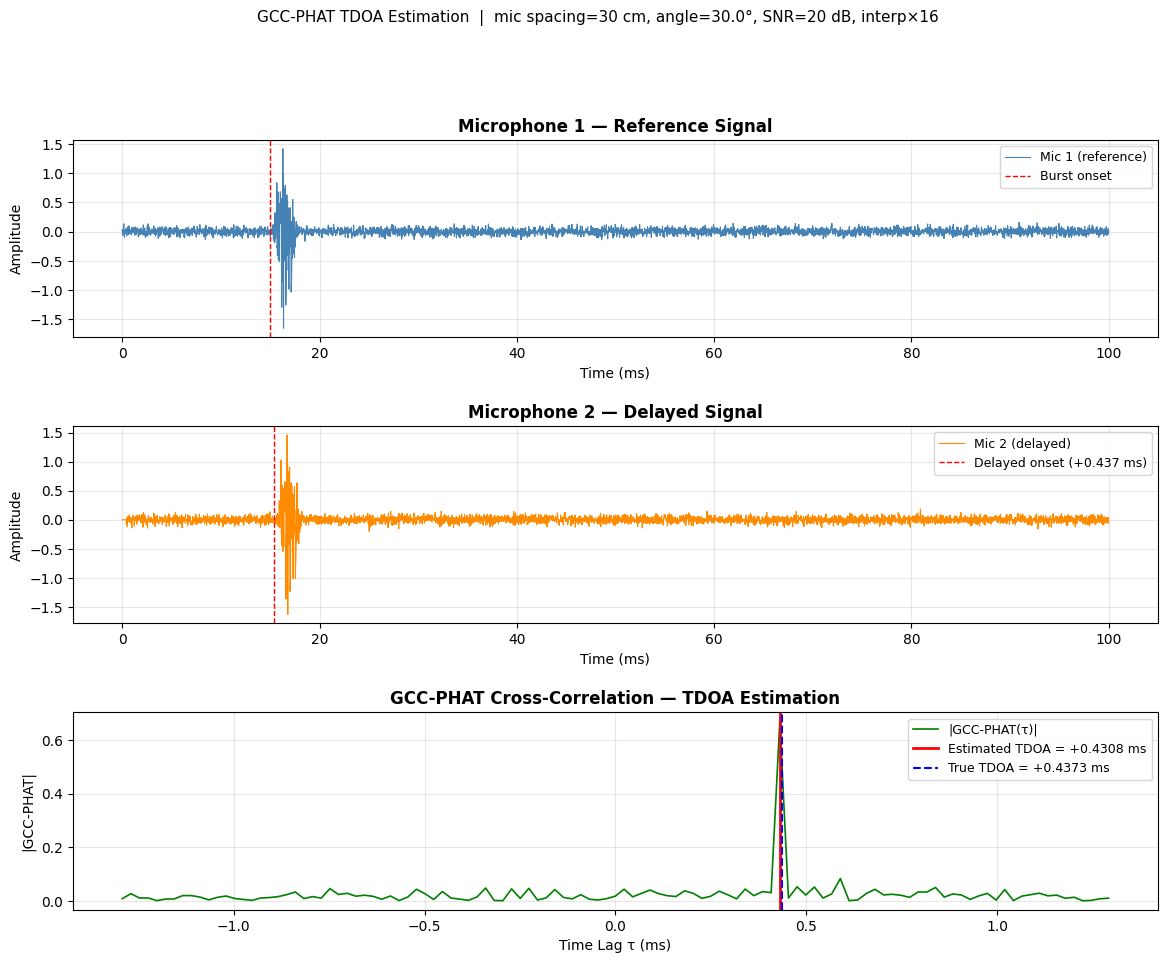

Figure saved as gcc_phat_result.png


In [8]:
# ── Cell 5: Visualise Signals + GCC-PHAT Output ───────────────────────────────

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# ── Panel 1: Mic 1 ───────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(t_axis * 1000, mic1, color='steelblue', lw=0.8, label='Mic 1 (reference)')
ax1.axvline(burst_start / FS * 1000, color='red', ls='--', lw=1, label=f'Burst onset')
ax1.set_title('Microphone 1 — Reference Signal', fontweight='bold')
ax1.set_ylabel('Amplitude')
ax1.set_xlabel('Time (ms)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Panel 2: Mic 2 ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(t_axis * 1000, mic2, color='darkorange', lw=0.8, label='Mic 2 (delayed)')
ax2.axvline((burst_start + true_tdoa_sa) / FS * 1000, color='red', ls='--', lw=1,
            label=f'Delayed onset (+{true_tdoa_ms:.3f} ms)')
ax2.set_title('Microphone 2 — Delayed Signal', fontweight='bold')
ax2.set_ylabel('Amplitude')
ax2.set_xlabel('Time (ms)')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Panel 3: GCC-PHAT cross-correlation ──────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(lags * 1000, np.abs(cc), color='green', lw=1.2, label='|GCC-PHAT(τ)|')
ax3.axvline(tau_est * 1000, color='red', ls='-', lw=2,
            label=f'Estimated TDOA = {tau_est*1000:+.4f} ms')
ax3.axvline(true_tdoa_s * 1000, color='blue', ls='--', lw=1.5,
            label=f'True TDOA = {true_tdoa_ms:+.4f} ms')
ax3.set_title('GCC-PHAT Cross-Correlation — TDOA Estimation', fontweight='bold')
ax3.set_ylabel('|GCC-PHAT|')
ax3.set_xlabel('Time Lag τ (ms)')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)

fig.suptitle(
    f'GCC-PHAT TDOA Estimation  |  mic spacing={MIC_D*100:.0f} cm, '
    f'angle={ANGLE}°, SNR={SNR_DB} dB, interp×{16}',
    fontsize=11, y=1.01
)
plt.savefig('gcc_phat_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as gcc_phat_result.png")

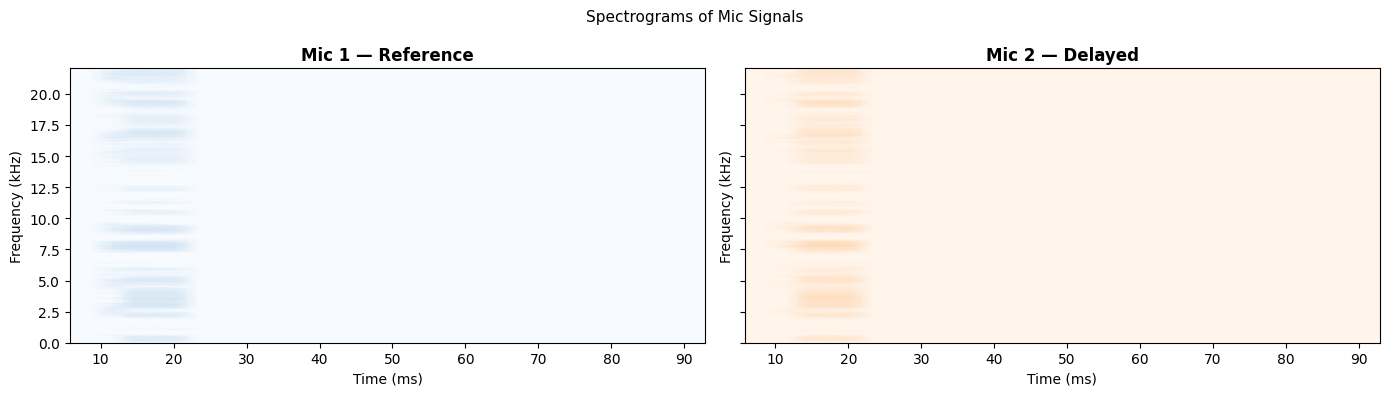

In [6]:
# ── Cell 6: Spectrogram Comparison (optional diagnostic) ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, signal_data, title, color in zip(
    axes, [mic1, mic2],
    ['Mic 1 — Reference', 'Mic 2 — Delayed'],
    ['Blues', 'Oranges']
):
    f, t_s, Sxx = sig_proc.spectrogram(signal_data, fs=FS, nperseg=512, noverlap=384)
    ax.pcolormesh(t_s * 1000, f / 1000, 10 * np.log10(Sxx + 1e-12),
                  cmap=color, shading='gouraud', vmin=-60, vmax=0)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Frequency (kHz)')
    ax.set_ylim(0, FS / 2000)

fig.suptitle('Spectrograms of Mic Signals', fontsize=11)
plt.tight_layout()
plt.savefig('spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()

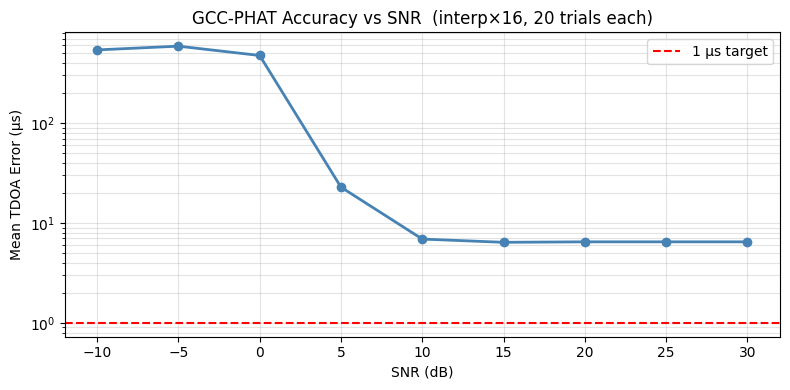

SNR vs TDOA error table:
  SNR (dB)    Error (µs)
       -10        540.88
        -5        589.59
         0        475.64
         5         22.84
        10          6.90
        15          6.41
        20          6.48
        25          6.48
        30          6.48


In [7]:
# ── Cell 7: Sweep — TDOA Accuracy vs SNR ─────────────────────────────────────
# Shows how GCC-PHAT degrades at low SNR — useful for system budget analysis.

snr_values  = np.arange(-10, 35, 5)          # dB
errors_us   = []
N_TRIALS    = 20

for snr_db in snr_values:
    trial_errors = []
    for _ in range(N_TRIALS):
        rng2       = np.random.default_rng()
        src        = np.zeros(N)
        src[burst_start:burst_start + burst_len] = (
            np.hanning(burst_len) * rng2.standard_normal(burst_len)
        )
        sp  = np.mean(src[burst_start:burst_start + burst_len] ** 2)
        ns  = np.sqrt(sp / (10 ** (snr_db / 10)))

        m1 = src.copy()       + rng2.standard_normal(N) * ns
        m2 = np.zeros(N)
        m2[true_tdoa_sa:] = src[:N - true_tdoa_sa] + rng2.standard_normal(N - true_tdoa_sa) * ns

        tau_t, _, _ = gcc_phat(m2, m1, fs=FS, max_tau=MIC_D / C_SOUND * 1.5, interp=16)
        trial_errors.append(abs(tau_t - true_tdoa_s) * 1e6)

    errors_us.append(np.mean(trial_errors))

plt.figure(figsize=(8, 4))
plt.semilogy(snr_values, errors_us, 'o-', color='steelblue', lw=2)
plt.axhline(1, color='red', ls='--', label='1 µs target')
plt.xlabel('SNR (dB)')
plt.ylabel('Mean TDOA Error (µs)')
plt.title(f'GCC-PHAT Accuracy vs SNR  (interp×16, {N_TRIALS} trials each)')
plt.legend()
plt.grid(True, which='both', alpha=0.35)
plt.tight_layout()
plt.savefig('snr_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print("SNR vs TDOA error table:")
print(f"{'SNR (dB)':>10}  {'Error (µs)':>12}")
for snr, err in zip(snr_values, errors_us):
    print(f"{snr:>10}  {err:>12.2f}")

## Summary & Next Steps

| Parameter | Value |
|---|---|
| Algorithm | GCC-PHAT (Knapp & Carter, 1976) |
| Reference code | [respeaker/mic_array](https://github.com/respeaker/mic_array/blob/master/gcc_phat.py) |
| Interpolation | 16× (sub-sample resolution ≈ 1.4 µs @ 44.1 kHz) |
| Mic spacing | 30 cm |
| Max physical TDOA | ~0.87 ms (endfire) |

### To extend to 4 microphones (your DE10-Nano build):
- Call `gcc_phat()` for each unique mic pair: (1,2), (1,3), (1,4), (2,3), (2,4), (3,4)
- Feed the 3+ independent TDOAs into Chan's or Fang's hyperbolic multilateration solver
- Replace the synthetic source with real ADC captures from the AD7606B / ADS8688

### Key tuning levers:
- **`interp`** — larger = finer sub-sample resolution, higher CPU cost
- **`max_tau`** — set to `mic_spacing / c_sound` × 1.2 to avoid false peaks
- **Pre-filter** — bandpass 1–10 kHz before calling `gcc_phat` to suppress infrasound and ADC noise